# Exploring IBM Fake Backends for Cloud Runs

This notebook surveys the fake backends available in `qiskit_ibm_runtime.fake_provider` that are relevant to our cloud simulation runs. Currently we only use **FakeFez** (Heron R2, 156 qubits). Here we explore backends across four architectures:

| Architecture | Qubits | Native 2Q Gate | Topology | Fake Backends |
|---|---|---|---|---|
| **Eagle r3** | 127 | ECR | Heavy-hex | FakeBrisbane, FakeSherbrooke, ... |
| **Heron R1** | 133 | CZ | Heavy-hex + tunable couplers | FakeTorino |
| **Heron R2** | 156 | CZ | Heavy-hex + tunable couplers | FakeFez, FakeMarrakesh |
| **Heron R3** | 156 | CZ | Same as R2 | None (use R2 as proxy) |

**Goal**: Understand the differences so we can parameterize `cloud_runs/common.py` to accept a backend flag.

## 1. Import and List All Available Fake Backends

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from qiskit_ibm_runtime.fake_provider import (
    FakeBrisbane,
    FakeSherbrooke,
    FakeTorino,
    FakeFez,
    FakeMarrakesh,
)

# Optional: try importing Nighthawk (added in qiskit-ibm-runtime v0.44+)
try:
    from qiskit_ibm_runtime.fake_provider import FakeNighthawk
    HAS_NIGHTHAWK = True
except ImportError:
    HAS_NIGHTHAWK = False
    print("FakeNighthawk not available (requires qiskit-ibm-runtime >= 0.44)")

print("Imports OK")

Imports OK


In [2]:
# List ALL fake backends from the provider
from qiskit_ibm_runtime.fake_provider import FakeProviderForBackendV2

provider = FakeProviderForBackendV2()
all_backends = provider.backends()

print(f"Total fake backends available: {len(all_backends)}\n")
print(f"{'Class':<30s} {'Name':<25s} {'Qubits':>6s}")
print("-" * 65)
for b in sorted(all_backends, key=lambda x: x.num_qubits, reverse=True):
    print(f"{type(b).__name__:<30s} {b.name:<25s} {b.num_qubits:>6d}")

Total fake backends available: 60

Class                          Name                      Qubits
-----------------------------------------------------------------
FakeFez                        fake_fez                     156
FakeMarrakesh                  fake_marrakesh               156
FakeTorino                     fake_torino                  133
FakeBrisbane                   fake_brisbane                127
FakeCusco                      fake_cusco                   127
FakeKawasaki                   fake_kawasaki                127
FakeKyiv                       fake_kyiv                    127
FakeKyoto                      fake_kyoto                   127
FakeOsaka                      fake_osaka                   127
FakeQuebec                     fake_quebec                  127
FakeSherbrooke                 fake_sherbrooke              127
FakeWashingtonV2               fake_washington              127
FakeNighthawk                  fake_nighthawk               120
Fak

## 2. Define Our Target Backends

We pick one representative backend per architecture:
- **Eagle r3**: `FakeBrisbane` (127 qubits, ECR native gate)
- **Heron R1**: `FakeTorino` (133 qubits, CZ native gate)
- **Heron R2**: `FakeFez` (156 qubits, CZ native gate) — current default
- **Heron R2 alt**: `FakeMarrakesh` (156 qubits, CZ native gate) — same arch, different calibration

In [3]:
# Instantiate the backends we care about
backends = {
    "eagle_r3": {"label": "Eagle r3 (FakeBrisbane)",  "backend": FakeBrisbane()},
    "heron_r1": {"label": "Heron R1 (FakeTorino)",    "backend": FakeTorino()},
    "heron_r2": {"label": "Heron R2 (FakeFez)",       "backend": FakeFez()},
    "heron_r2_alt": {"label": "Heron R2 (FakeMarrakesh)", "backend": FakeMarrakesh()},
}

if HAS_NIGHTHAWK:
    backends["nighthawk_r1"] = {"label": "Nighthawk R1 (FakeNighthawk)", "backend": FakeNighthawk()}

print(f"{'Key':<16s} {'Label':<35s} {'Qubits':>6s}  Basis Gates (native 2Q)")
print("-" * 95)
for key, info in backends.items():
    b = info["backend"]
    ops = b.operation_names
    # Identify native 2Q gate
    two_q_gates = [g for g in ['ecr', 'cz', 'cx'] if g in ops]
    print(f"{key:<16s} {info['label']:<35s} {b.num_qubits:>6d}  {two_q_gates}")

Key              Label                               Qubits  Basis Gates (native 2Q)
-----------------------------------------------------------------------------------------------
eagle_r3         Eagle r3 (FakeBrisbane)                127  ['ecr']
heron_r1         Heron R1 (FakeTorino)                  133  ['cz']
heron_r2         Heron R2 (FakeFez)                     156  ['cz']
heron_r2_alt     Heron R2 (FakeMarrakesh)               156  ['cz']
nighthawk_r1     Nighthawk R1 (FakeNighthawk)           120  ['cz']


## 3. Compare Basis Gates

**Key difference**: Eagle uses **ECR** (Echoed Cross-Resonance) as its native 2Q gate, while all Heron revisions use **CZ**. This matters because our circuits and `build_simulator()` currently hardcode `basis_gates = ["cz", "id", "rz", "sx", "x"]`.

In [4]:
for key, info in backends.items():
    b = info["backend"]
    ops = sorted(b.operation_names)
    # Filter to just the gate operations (exclude measure, reset, delay, control flow)
    control_flow = {'measure', 'reset', 'delay', 'if_else', 'for_loop', 'switch_case'}
    gates_only = [g for g in ops if g not in control_flow]
    print(f"{info['label']}")
    print(f"  All operations: {ops}")
    print(f"  Gate operations: {gates_only}")
    print()

Eagle r3 (FakeBrisbane)
  All operations: ['delay', 'ecr', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gate operations: ['ecr', 'id', 'rz', 'sx', 'x']

Heron R1 (FakeTorino)
  All operations: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gate operations: ['cz', 'id', 'rz', 'sx', 'x']

Heron R2 (FakeFez)
  All operations: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gate operations: ['cz', 'id', 'rz', 'sx', 'x']

Heron R2 (FakeMarrakesh)
  All operations: ['cz', 'delay', 'for_loop', 'id', 'if_else', 'measure', 'reset', 'rz', 'switch_case', 'sx', 'x']
  Gate operations: ['cz', 'id', 'rz', 'sx', 'x']

Nighthawk R1 (FakeNighthawk)
  All operations: ['cz', 'delay', 'id', 'if_else', 'measure', 'reset', 'rz', 'sx', 'x']
  Gate operations: ['cz', 'id', 'rz', 'sx', 'x']



## 4. Compare Coherence Times (T1, T2)

Coherence times directly affect how much noise accumulates during a circuit. Longer T1/T2 = better qubits.

In [5]:
coherence_data = {}

for key, info in backends.items():
    b = info["backend"]
    target = b.target
    
    t1_list = []
    t2_list = []
    for qubit in range(b.num_qubits):
        qp = target.qubit_properties[qubit] if target.qubit_properties else None
        if qp:
            if qp.t1 is not None:
                t1_list.append(qp.t1 * 1e6)  # convert to μs
            if qp.t2 is not None:
                t2_list.append(qp.t2 * 1e6)
    
    coherence_data[key] = {
        "label": info["label"],
        "t1": np.array(t1_list) if t1_list else None,
        "t2": np.array(t2_list) if t2_list else None,
    }
    
    if t1_list:
        print(f"{info['label']}")
        print(f"  T1: mean={np.mean(t1_list):.1f} μs, median={np.median(t1_list):.1f} μs, "
              f"range=[{np.min(t1_list):.1f}, {np.max(t1_list):.1f}] μs")
        print(f"  T2: mean={np.mean(t2_list):.1f} μs, median={np.median(t2_list):.1f} μs, "
              f"range=[{np.min(t2_list):.1f}, {np.max(t2_list):.1f}] μs")
        print()

Eagle r3 (FakeBrisbane)
  T1: mean=233.7 μs, median=232.0 μs, range=[9.9, 425.2] μs
  T2: mean=160.6 μs, median=150.0 μs, range=[17.1, 411.5] μs

Heron R1 (FakeTorino)
  T1: mean=173.6 μs, median=185.0 μs, range=[3.2, 307.7] μs
  T2: mean=145.2 μs, median=140.9 μs, range=[6.1, 349.9] μs

Heron R2 (FakeFez)
  T1: mean=145.3 μs, median=144.9 μs, range=[27.1, 274.4] μs
  T2: mean=90.5 μs, median=88.0 μs, range=[6.0, 302.8] μs

Heron R2 (FakeMarrakesh)
  T1: mean=207.1 μs, median=197.4 μs, range=[6.8, 499.1] μs
  T2: mean=147.0 μs, median=118.4 μs, range=[0.2, 534.8] μs

Nighthawk R1 (FakeNighthawk)
  T1: mean=256.1 μs, median=272.8 μs, range=[16.4, 403.9] μs
  T2: mean=329.1 μs, median=341.6 μs, range=[14.8, 615.6] μs



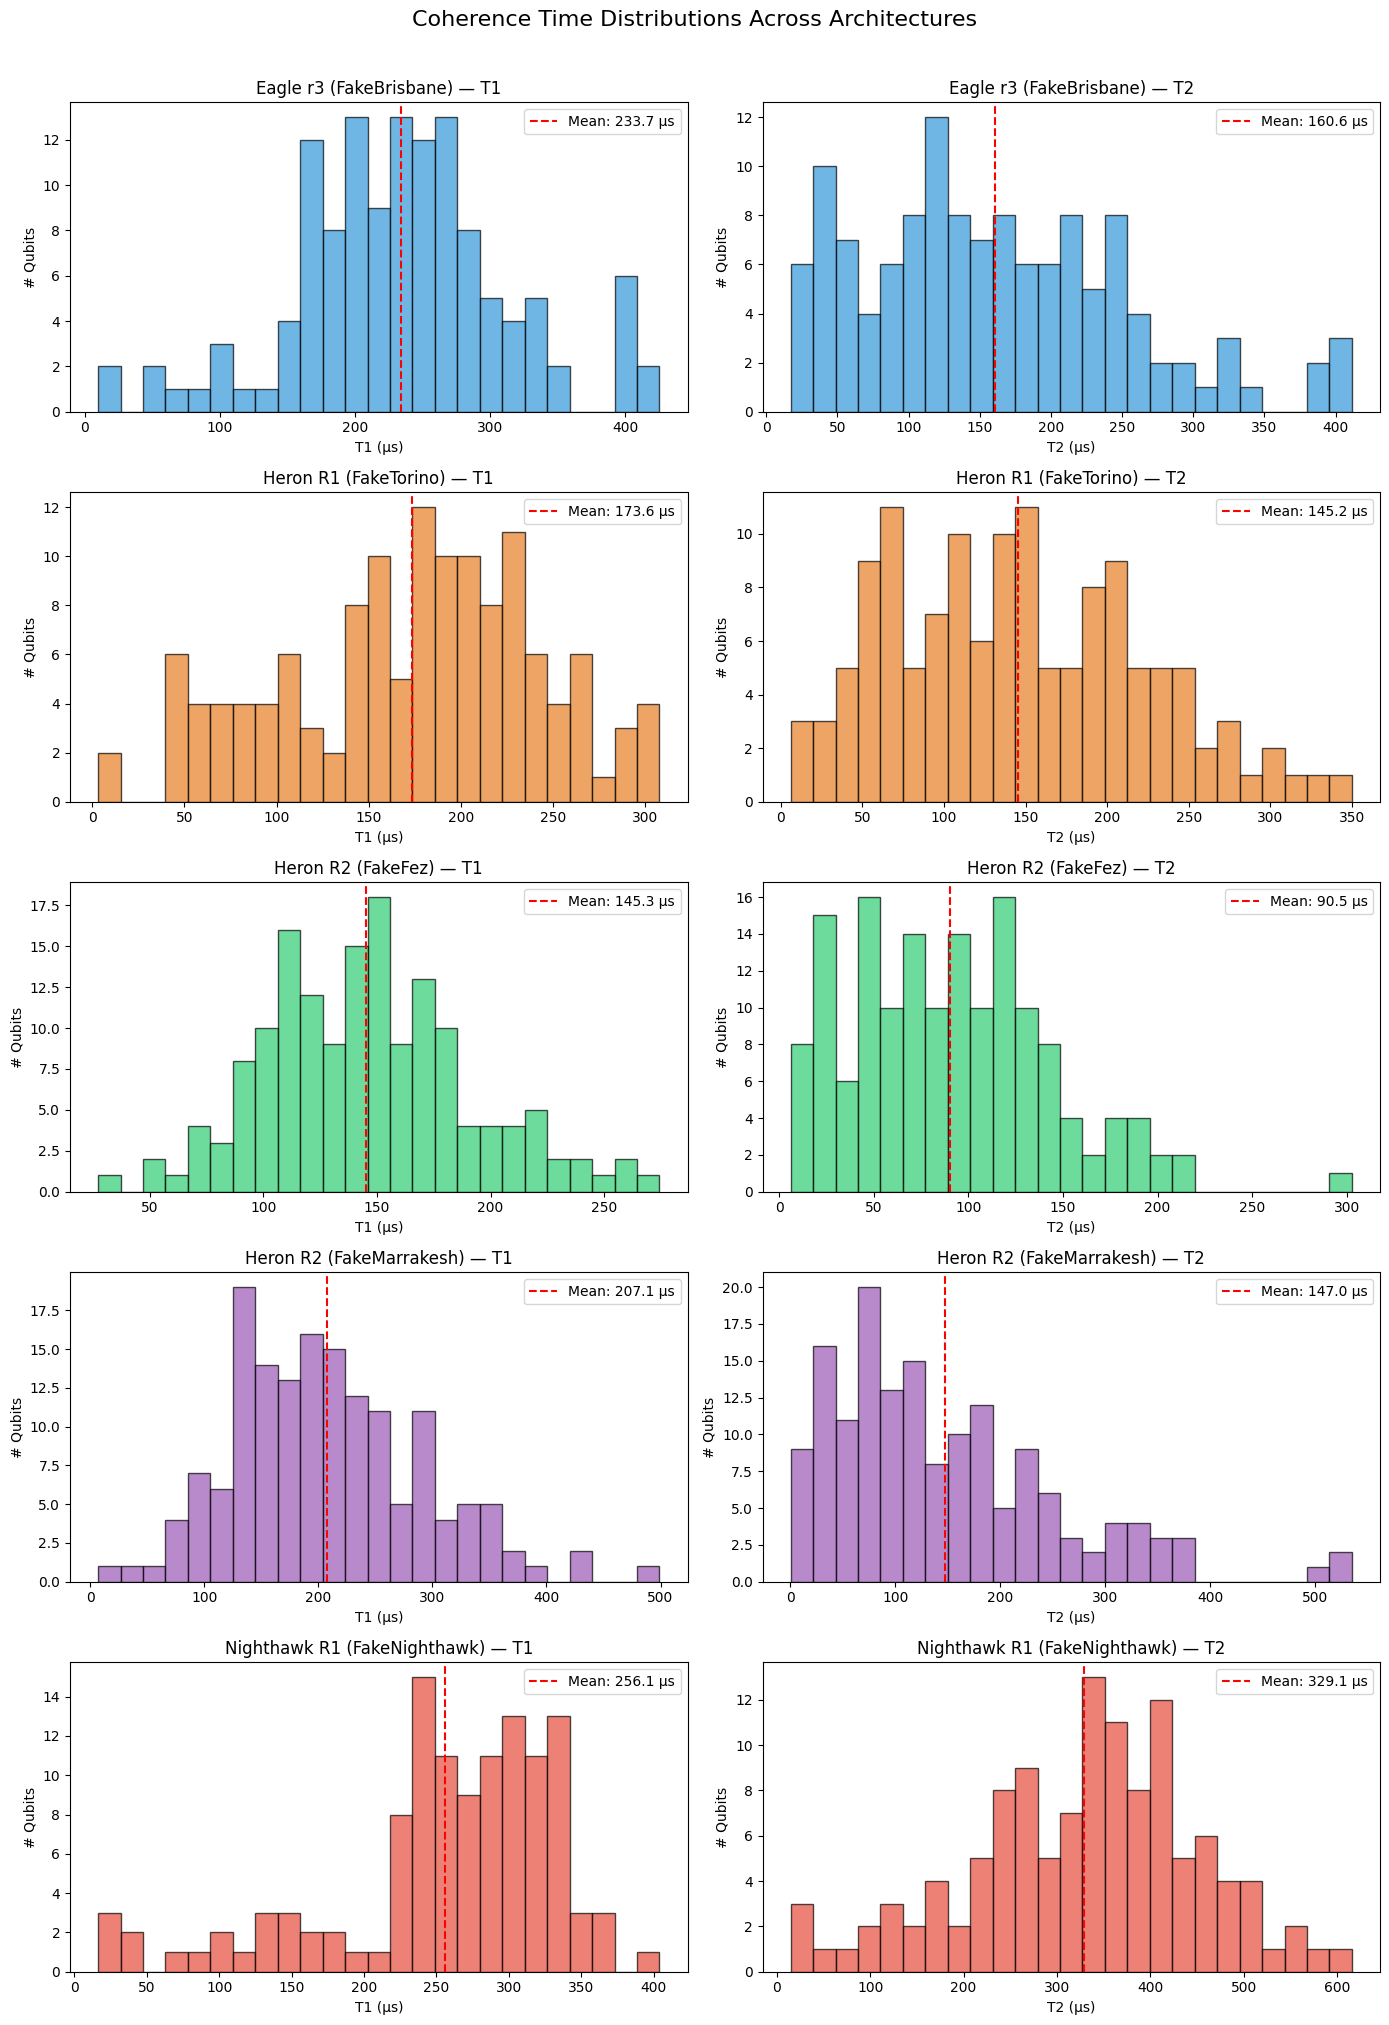

In [6]:
# Plot T1 and T2 distributions side by side
plot_keys = [k for k in backends if coherence_data[k]["t1"] is not None]
n = len(plot_keys)

fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n), squeeze=False)
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for i, key in enumerate(plot_keys):
    cd = coherence_data[key]
    
    # T1
    axes[i, 0].hist(cd["t1"], bins=25, color=colors[i % len(colors)],
                    edgecolor='black', alpha=0.7)
    axes[i, 0].axvline(np.mean(cd["t1"]), color='red', linestyle='--',
                       label=f'Mean: {np.mean(cd["t1"]):.1f} μs')
    axes[i, 0].set_xlabel('T1 (μs)')
    axes[i, 0].set_ylabel('# Qubits')
    axes[i, 0].set_title(f'{cd["label"]} — T1')
    axes[i, 0].legend()
    
    # T2
    axes[i, 1].hist(cd["t2"], bins=25, color=colors[i % len(colors)],
                    edgecolor='black', alpha=0.7)
    axes[i, 1].axvline(np.mean(cd["t2"]), color='red', linestyle='--',
                       label=f'Mean: {np.mean(cd["t2"]):.1f} μs')
    axes[i, 1].set_xlabel('T2 (μs)')
    axes[i, 1].set_ylabel('# Qubits')
    axes[i, 1].set_title(f'{cd["label"]} — T2')
    axes[i, 1].legend()

fig.suptitle('Coherence Time Distributions Across Architectures', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

## 5. Compare Gate Errors (1Q and 2Q)

In [7]:
gate_error_data = {}

for key, info in backends.items():
    b = info["backend"]
    target = b.target
    
    # Identify the native 2Q gate for this backend
    if 'ecr' in target.operation_names:
        gate_2q = 'ecr'
    elif 'cz' in target.operation_names:
        gate_2q = 'cz'
    else:
        gate_2q = None
    
    # Collect 1Q errors (sx gate as representative)
    errors_1q = []
    if 'sx' in target.operation_names:
        for qargs in target.qargs_for_operation_name('sx'):
            props = target['sx'][qargs]
            if props and props.error is not None and props.error > 0:
                errors_1q.append(props.error)
    
    # Collect 2Q errors
    errors_2q = []
    if gate_2q and gate_2q in target.operation_names:
        for qargs in target.qargs_for_operation_name(gate_2q):
            props = target[gate_2q][qargs]
            if props and props.error is not None and props.error > 0:
                errors_2q.append(props.error)
    
    gate_error_data[key] = {
        "label": info["label"],
        "gate_2q_name": gate_2q,
        "errors_1q": np.array(errors_1q) if errors_1q else None,
        "errors_2q": np.array(errors_2q) if errors_2q else None,
    }
    
    print(f"{info['label']}  (native 2Q: {gate_2q})")
    if errors_1q:
        print(f"  1Q (sx) errors: mean={np.mean(errors_1q):.2e}, "
              f"median={np.median(errors_1q):.2e}, range=[{np.min(errors_1q):.2e}, {np.max(errors_1q):.2e}]")
    else:
        print(f"  1Q (sx) errors: not available")
    if errors_2q:
        print(f"  2Q ({gate_2q}) errors: mean={np.mean(errors_2q):.2e}, "
              f"median={np.median(errors_2q):.2e}, range=[{np.min(errors_2q):.2e}, {np.max(errors_2q):.2e}]")
    else:
        print(f"  2Q ({gate_2q}) errors: not available")
    print()

Eagle r3 (FakeBrisbane)  (native 2Q: ecr)
  1Q (sx) errors: mean=1.49e-03, median=2.43e-04, range=[8.87e-05, 1.41e-01]
  2Q (ecr) errors: mean=1.96e-02, median=7.72e-03, range=[3.66e-03, 1.00e+00]

Heron R1 (FakeTorino)  (native 2Q: cz)
  1Q (sx) errors: mean=7.28e-04, median=2.71e-04, range=[1.14e-04, 1.74e-02]
  2Q (cz) errors: mean=8.00e-02, median=4.19e-03, range=[1.50e-03, 1.00e+00]

Heron R2 (FakeFez)  (native 2Q: cz)
  1Q (sx) errors: mean=2.87e-04, median=2.29e-04, range=[1.00e-04, 2.49e-03]
  2Q (cz) errors: mean=4.51e-02, median=3.90e-03, range=[2.14e-03, 1.00e+00]

Heron R2 (FakeMarrakesh)  (native 2Q: cz)
  1Q (sx) errors: mean=8.58e-04, median=2.30e-04, range=[6.88e-05, 4.19e-02]
  2Q (cz) errors: mean=8.06e-02, median=3.29e-03, range=[1.04e-03, 1.00e+00]

Nighthawk R1 (FakeNighthawk)  (native 2Q: cz)
  1Q (sx) errors: mean=8.61e-03, median=1.48e-04, range=[6.12e-05, 1.00e+00]
  2Q (cz) errors: mean=2.83e-03, median=2.71e-03, range=[1.05e-03, 9.78e-03]



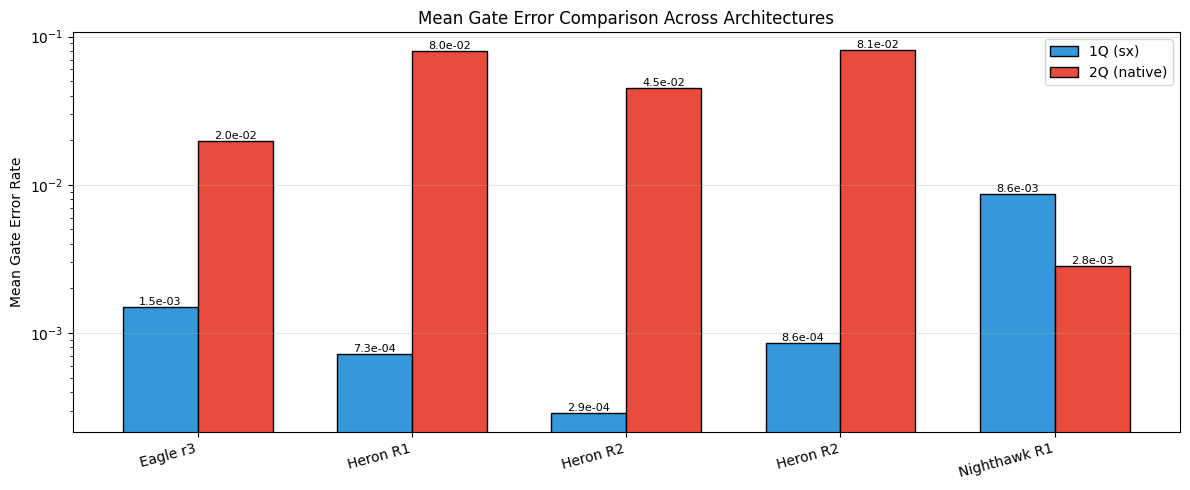

In [8]:
# Bar chart comparison of mean gate errors
plot_keys = list(backends.keys())
labels = [gate_error_data[k]["label"].split(" (")[0] for k in plot_keys]

mean_1q = []
mean_2q = []
for k in plot_keys:
    e1 = gate_error_data[k]["errors_1q"]
    e2 = gate_error_data[k]["errors_2q"]
    mean_1q.append(np.mean(e1) if e1 is not None else 0)
    mean_2q.append(np.mean(e2) if e2 is not None else 0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, mean_1q, width, label='1Q (sx)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, mean_2q, width, label='2Q (native)', color='#e74c3c', edgecolor='black')

ax.set_ylabel('Mean Gate Error Rate')
ax.set_title('Mean Gate Error Comparison Across Architectures')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend()
ax.set_yscale('log')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.1e}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{bar.get_height():.1e}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Compare Coupling Map Connectivity

In [9]:
import rustworkx as rx

print(f"{'Backend':<35s} {'Qubits':>6s} {'Edges':>6s} {'Avg Degree':>10s} {'Max Degree':>10s}  {'Diameter':>8s}")
print("-" * 85)

for key, info in backends.items():
    b = info["backend"]
    cm = b.coupling_map
    edges = cm.get_edges()
    
    # Build undirected graph for analysis
    g = rx.PyGraph()
    g.add_nodes_from(range(b.num_qubits))
    # Deduplicate edges (coupling map may have both directions)
    undirected_edges = set()
    for e in edges:
        undirected_edges.add((min(e), max(e)))
    g.add_edges_from_no_data(list(undirected_edges))
    
    degrees = [g.degree(n) for n in range(g.num_nodes())]
    avg_deg = np.mean(degrees)
    max_deg = max(degrees)
    
    # Diameter (longest shortest path) — can be slow for large graphs
    try:
        # Use BFS from a few nodes to estimate diameter
        sample_nodes = [0, b.num_qubits // 2, b.num_qubits - 1]
        max_dist = 0
        for sn in sample_nodes:
            dists = rx.dijkstra_shortest_path_lengths(g, sn, lambda _: 1)
            if dists:
                max_dist = max(max_dist, max(dists.values()))
        diameter_est = f"~{int(max_dist)}"
    except Exception:
        diameter_est = "N/A"
    
    print(f"{info['label']:<35s} {b.num_qubits:>6d} {len(undirected_edges):>6d} {avg_deg:>10.2f} {max_deg:>10d}  {diameter_est:>8s}")

Backend                             Qubits  Edges Avg Degree Max Degree  Diameter
-------------------------------------------------------------------------------------
Eagle r3 (FakeBrisbane)                127    144       2.27          3       ~26
Heron R1 (FakeTorino)                  133    150       2.26          3       ~27
Heron R2 (FakeFez)                     156    176       2.26          3       ~32
Heron R2 (FakeMarrakesh)               156    176       2.26          3       ~32
Nighthawk R1 (FakeNighthawk)           120    218       3.63          4       ~20


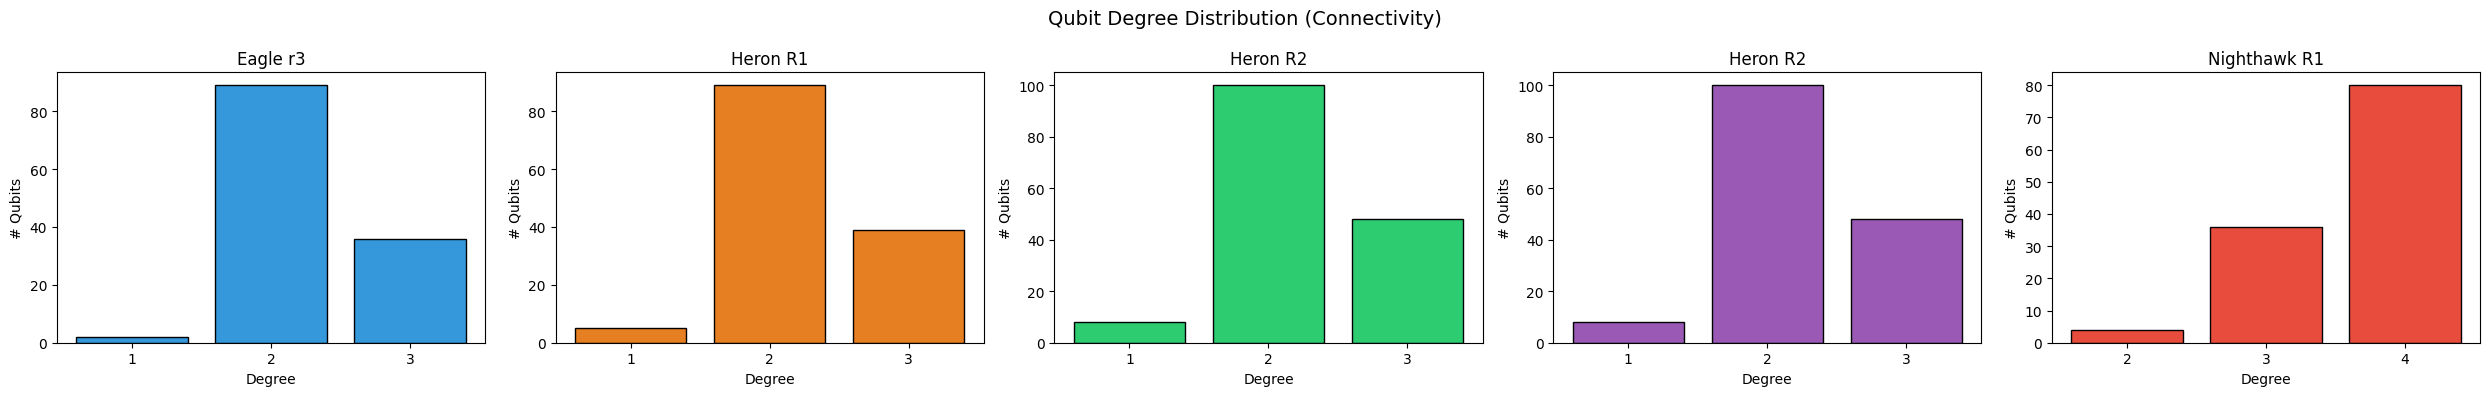

In [10]:
# Degree distribution comparison
fig, axes = plt.subplots(1, len(backends), figsize=(5 * len(backends), 4), squeeze=False)
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c']

for i, (key, info) in enumerate(backends.items()):
    b = info["backend"]
    cm = b.coupling_map
    edges = cm.get_edges()
    
    g = rx.PyGraph()
    g.add_nodes_from(range(b.num_qubits))
    undirected_edges = set()
    for e in edges:
        undirected_edges.add((min(e), max(e)))
    g.add_edges_from_no_data(list(undirected_edges))
    
    degrees = [g.degree(n) for n in range(g.num_nodes())]
    unique_degs = sorted(set(degrees))
    deg_counts = [degrees.count(d) for d in unique_degs]
    
    axes[0, i].bar(unique_degs, deg_counts, color=colors[i % len(colors)], edgecolor='black')
    axes[0, i].set_xlabel('Degree')
    axes[0, i].set_ylabel('# Qubits')
    axes[0, i].set_title(info['label'].split(' (')[0])
    axes[0, i].set_xticks(unique_degs)

fig.suptitle('Qubit Degree Distribution (Connectivity)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Visualize Coupling Map Topologies

In [11]:
from qiskit.visualization import plot_gate_map

for key, info in backends.items():
    b = info["backend"]
    print(f"\n--- {info['label']} ---")
    try:
        fig = plot_gate_map(b, plot_directed=False, figsize=(12, 8))
        fig.suptitle(f"{info['label']} ({b.num_qubits} qubits)", fontsize=14)
        fig.tight_layout()
        plt.show()
    except Exception as e:
        print(f"  plot_gate_map failed: {e}")
        print(f"  (This is expected for some backends without layout data)")


--- Eagle r3 (FakeBrisbane) ---

--- Heron R1 (FakeTorino) ---

--- Heron R2 (FakeFez) ---

--- Heron R2 (FakeMarrakesh) ---

--- Nighthawk R1 (FakeNighthawk) ---


## 8. Impact on `build_simulator()` — What Would Need to Change

Our current `cloud_runs/common.py` hardcodes FakeFez. Here's a summary of what changes per backend:

| Property | Eagle r3 (Brisbane) | Heron R1 (Torino) | Heron R2 (Fez) | Heron R2 (Marrakesh) |
|---|---|---|---|---|
| Native 2Q gate | `ecr` | `cz` | `cz` | `cz` |
| Basis gates | `ecr,id,rz,sx,x` | `cz,id,rz,sx,x` | `cz,id,rz,sx,x` | `cz,id,rz,sx,x` |
| Qubits | 127 | 133 | 156 | 156 |
| Noise characteristics | Different T1/T2/error | Different T1/T2/error | Current default | Same arch, different calibration |

**Key change for Eagle**: The 2Q gate switches from `cz` to `ecr`, so we'd need to update the `basis_gates` list and the depolarizing noise model's 2Q gate target.

In [12]:
# Demonstrate how to build a noise model for each backend generically
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


def build_simulator_generic(backend_key: str, noise_type: str = "depolarizing",
                            num_circuit_qubits: int = 100, error_rate_2q: float = 0.01):
    """
    Generic version of build_simulator that accepts a backend key.
    
    Supported keys: 'eagle_r3', 'heron_r1', 'heron_r2', 'heron_r2_marrakesh'
    """
    BACKEND_MAP = {
        "eagle_r3":          (FakeBrisbane,   ["ecr", "id", "rz", "sx", "x"]),
        "heron_r1":          (FakeTorino,     ["cz",  "id", "rz", "sx", "x"]),
        "heron_r2":          (FakeFez,        ["cz",  "id", "rz", "sx", "x"]),
        "heron_r2_marrakesh":(FakeMarrakesh,  ["cz",  "id", "rz", "sx", "x"]),
    }
    
    if backend_key not in BACKEND_MAP:
        raise ValueError(f"Unknown backend_key '{backend_key}'. Choose from: {list(BACKEND_MAP.keys())}")
    
    BackendClass, basis_gates = BACKEND_MAP[backend_key]
    fake_backend = BackendClass()
    
    # Identify the native 2Q gate
    gate_2q = "ecr" if "ecr" in basis_gates else "cz"
    
    if noise_type == "thermal":
        noise_model = NoiseModel.from_backend(
            fake_backend, readout_error=False, gate_error=False, thermal_relaxation=True
        )
    elif noise_type == "depolarizing":
        target = fake_backend.target
        noise_model = NoiseModel()
        
        # 1Q depolarizing from backend calibration
        for gate in ['sx', 'x', 'rz', 'id']:
            if gate not in target.operation_names:
                continue
            for qargs in target.qargs_for_operation_name(gate):
                props = target[gate][qargs]
                if props and props.error and props.error > 0:
                    noise_model.add_quantum_error(depolarizing_error(props.error, 1), gate, list(qargs))
        
        # 2Q uniform depolarizing on the native gate
        noise_model.add_all_qubit_quantum_error(
            depolarizing_error(error_rate_2q, 2), gate_2q
        )
    else:
        raise ValueError(f"Unknown noise_type: {noise_type}")
    
    noisy_sim = AerSimulator(noise_model=noise_model, method="matrix_product_state")
    return noisy_sim, basis_gates, fake_backend


# Test it for each backend
for bk in ["eagle_r3", "heron_r1", "heron_r2", "heron_r2_marrakesh"]:
    sim, gates, backend = build_simulator_generic(bk)
    print(f"{bk:<22s} -> {type(backend).__name__:<16s} qubits={backend.num_qubits}  basis={gates}")

print("\nAll backends build successfully!")

eagle_r3               -> FakeBrisbane     qubits=127  basis=['ecr', 'id', 'rz', 'sx', 'x']
heron_r1               -> FakeTorino       qubits=133  basis=['cz', 'id', 'rz', 'sx', 'x']
heron_r2               -> FakeFez          qubits=156  basis=['cz', 'id', 'rz', 'sx', 'x']
heron_r2_marrakesh     -> FakeMarrakesh    qubits=156  basis=['cz', 'id', 'rz', 'sx', 'x']

All backends build successfully!


## 9. Summary of 2Q Gate Error Distributions

This is the most important comparison for our simulation fidelity — 2Q gate errors dominate circuit noise.

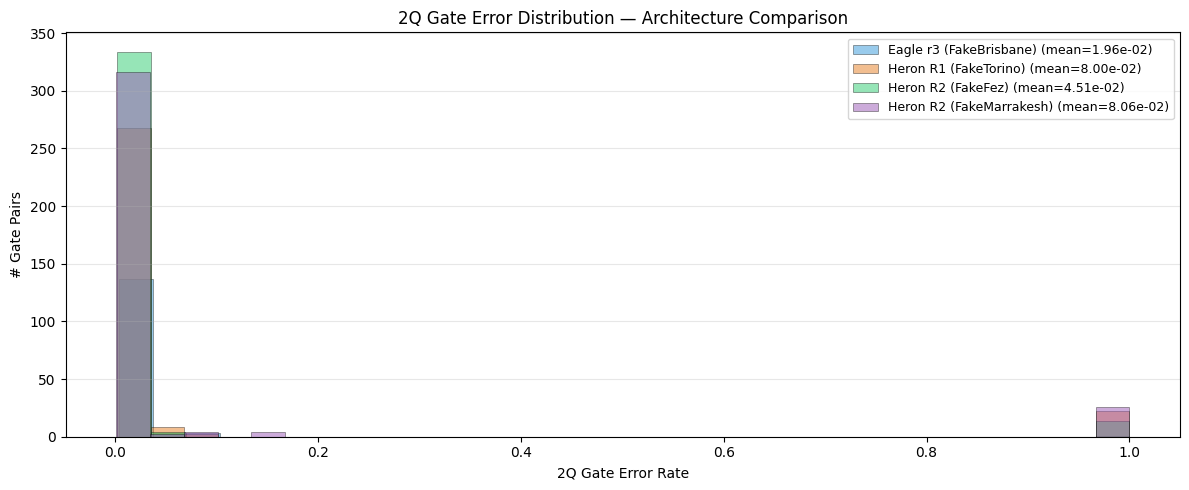

In [13]:
# Overlay 2Q error histograms
fig, ax = plt.subplots(figsize=(12, 5))

colors_map = {
    "eagle_r3": '#3498db',
    "heron_r1": '#e67e22',
    "heron_r2": '#2ecc71',
    "heron_r2_alt": '#9b59b6',
}

for key in ["eagle_r3", "heron_r1", "heron_r2", "heron_r2_alt"]:
    e2 = gate_error_data[key]["errors_2q"]
    if e2 is not None and len(e2) > 0:
        label = f"{gate_error_data[key]['label']} (mean={np.mean(e2):.2e})"
        ax.hist(e2, bins=30, alpha=0.5, label=label,
                color=colors_map.get(key, 'gray'), edgecolor='black', linewidth=0.5)

ax.set_xlabel('2Q Gate Error Rate')
ax.set_ylabel('# Gate Pairs')
ax.set_title('2Q Gate Error Distribution — Architecture Comparison')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Conclusions & Recommendations

### Available backends for cloud runs:

| Flag value | Backend | Architecture | Qubits | Native 2Q | Notes |
|---|---|---|---|---|---|
| `eagle_r3` | FakeBrisbane | Eagle r3 | 127 | ECR | Different gate set — needs `ecr` in basis_gates |
| `heron_r1` | FakeTorino | Heron R1 | 133 | CZ | Same gate set as current, different noise profile |
| `heron_r2` | FakeFez | Heron R2 | 156 | CZ | **Current default** |
| `heron_r2_marrakesh` | FakeMarrakesh | Heron R2 | 156 | CZ | Same arch, different calibration snapshot |

### Heron R3:
No `FakeHeronR3` backend exists yet. Heron R3 uses the same topology and gate set as R2 (156 qubits, CZ native), just with better manufacturing. **Use FakeFez/FakeMarrakesh as a proxy** — the noise will be pessimistic (R3 has better fidelity in practice).

### Key implementation consideration:
- For **Heron backends** (R1, R2): Drop-in replacement — same `cz` basis gate, just swap the backend class
- For **Eagle**: Need to change `basis_gates` to include `ecr` instead of `cz`, and update the 2Q noise target in `_build_depolarizing_noise_model()`
- The generic `build_simulator_generic()` function above handles this automatically